# Projet du cours de Machine Learning : analyse du dataset d'OpenFoodFact

# Prediction du nutriscore

## Chargement des données 

### A partir du format csv

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [1]:
url = "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz"


In [41]:
raw_df = pd.read_csv(url, sep='\t', low_memory=False, nrows=10000)
raw_df

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,...,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,54,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1740205422,2025-02-22T06:23:42Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1673620307,2023-01-13T14:31:47Z,1750061386,2025-06-16T08:09:46Z,bodysupport,1750061386,2025-06-16T08:09:46Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,114,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1580066482,2020-01-26T19:21:22Z,1751035658,2025-06-27T14:47:38Z,teolemon,1751035658,2025-06-27T14:47:38Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,431,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1714301712,2024-04-28T10:55:12Z,1714301721,2024-04-28T10:55:21Z,kiliweb,1714301721,2024-04-28T10:55:21Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,105,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1572117743,2019-10-26T19:22:23Z,1738073570,2025-01-28T14:12:50Z,NaN,1743653496,2025-04-03T04:11:36Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1111015989,http://world-en.openfoodfacts.org/product/0001...,macrofactor,1774136099,2026-03-21T23:34:59Z,1774136099,2026-03-21T23:34:59Z,macrofactor,1774136099,2026-03-21T23:34:59Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9996,1111018186,http://world-en.openfoodfacts.org/product/0001...,org-label-non-gmo-project,1718833779,2024-06-19T21:49:39Z,1728358923,2024-10-08T03:42:03Z,org-label-non-gmo-project,1728358923,2024-10-08T03:42:03Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9997,1111022310,http://world-en.openfoodfacts.org/product/0001...,macrofactor,1728699161,2024-10-12T02:12:41Z,1728699161,2024-10-12T02:12:41Z,macrofactor,1728699161,2024-10-12T02:12:41Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9998,1111035796,http://world-en.openfoodfacts.org/product/0001...,macrofactor,1751556054,2025-07-03T15:20:54Z,1751556055,2025-07-03T15:20:55Z,macrofactor,1751556055,2025-07-03T15:20:55Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# les qui vont nous interesser
cols = [
    'energy_100g', 'fat_100g', 'saturated-fat_100g', 
    'sugars_100g', 'fiber_100g', 'proteins_100g', 'carbohydrates_100g',
    'salt_100g', 'nutriscore_score'
]

In [ ]:
reader = pd.read_csv(
        url, compression='gzip', sep='\t',
        on_bad_lines='skip', chunksize=100000,
        low_memory=False, usecols=cols
    )

In [ ]:
total_rows = 0
for chunk in reader:
    total_rows += len(chunk)

print(f"Taille totale du dataset : {total_rows} lignes")
# Taille totale du dataset : 4465020 lignes

In [47]:
chunks = []
for i, chunk in enumerate(reader):
    print(f"Traitement du bloc n°{i} (lignes {i*reader.chunksize} à {(i+1)*reader.chunksize})")
    chunks.append(chunk)
    if i == 2: 
        break

df = pd.concat(chunks)
df


Traitement du bloc n°0 (lignes 0 à 100000)
Traitement du bloc n°1 (lignes 100000 à 200000)
Traitement du bloc n°2 (lignes 200000 à 300000)


,nutriscore_score,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
299995,NaN,1968.0,22.0,6.00,56.0,28.0,4.0,10.0,NaN
299996,NaN,2230.0,35.0,3.75,35.0,0.0,NaN,20.0,NaN
299997,NaN,1487.5,0.0,0.00,87.5,67.5,0.0,0.0,NaN
299998,-1.0,2484.0,46.0,8.00,28.0,6.0,NaN,18.0,0.300


In [52]:
def plot_missing_values(df, threshold=2):
    """
    Calcule et affiche le pourcentage de NaNs par colonne au-delà d'un seuil.
    """
    # Calcul des pourcentages
    percent_missing = df.isnull().sum() * 100 / len(df)
    
    # Filtrage selon le seuil
    filtered = percent_missing[percent_missing > threshold].sort_values(ascending=False)
    
    # Visualisation
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=filtered.values, y=filtered.index, hue=filtered.index, palette='viridis', legend=False)
    
    ax.set_title(f"Colonnes avec > {threshold}% de valeurs manquantes des {reader.chunksize*(i+1)} premieres lignes")
    ax.set_xlabel("Pourcentage de NaNs (%)")
    plt.tight_layout()
    
    return ax

<Axes: title={'center': 'Colonnes avec > 2% de valeurs manquantes des 300000 premieres lignes'}, xlabel='Pourcentage de NaNs (%)', ylabel='None'>

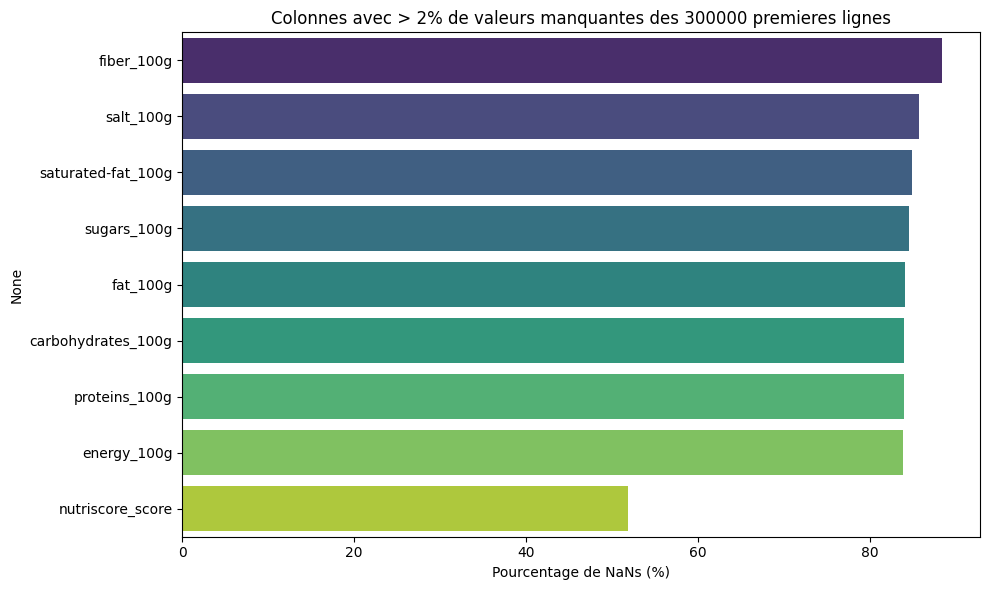

In [53]:
plot_missing_values(df)

In [56]:
def clean_nutriscore_outliers(df, target='nutriscore_score'):
    """
    Supprime les valeurs aberrantes selon les standards de nutrition 
    et les limites officielles du Nutri-Score.
    """
    # 1. Filtre de réalisme pour le score cible (-15 à +40)
    # On garde les lignes dans l'intervalle officiel
    df = df[(df[target] >= -15) & (df[target] <= 40)]

    # 2. Filtre sur les nutriments (doivent être entre 0 et 100g)
    nutri_cols = [
        'fat_100g', 'saturated-fat_100g', 'sugars_100g', 
        'proteins_100g', 'salt_100g', 'fiber_100g', 'carbohydrates_100g'
    ]
    
    for col in nutri_cols:
        if col in df.columns:
            # On élimine les valeurs impossibles (>100g ou <0g)
            df = df[(df[col] >= 0) & (df[col] <= 100)]
    
    # 3. Filtre sur l'énergie (max théorique autour de 3700-4000 kJ pour de l'huile pure)
    if 'energy_100g' in df.columns:
        df = df[(df['energy_100g'] >= 0) & (df['energy_100g'] < 4000)]
        
    return df

In [57]:
df_cleaned = clean_nutriscore_outliers(df)

In [59]:
df_cleaned.size

162063

<Axes: title={'center': 'Colonnes avec > 2% de valeurs manquantes des 300000 premieres lignes'}, xlabel='Pourcentage de NaNs (%)'>

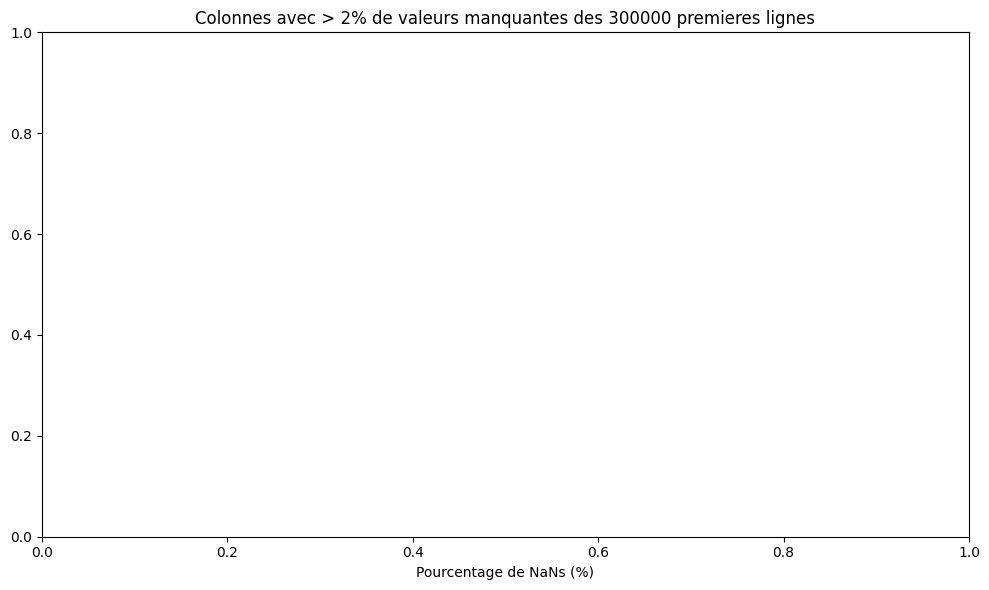

In [58]:
plot_missing_values(df_cleaned)

In [54]:
print(df.isna().sum())

nutriscore_score      155732
energy_100g           251514
fat_100g              252161
saturated-fat_100g    254930
carbohydrates_100g    252138
sugars_100g           253879
fiber_100g            265240
proteins_100g         252067
salt_100g             257122
dtype: int64


/workspaces/Openfoodfact/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/workspaces/Openfoodfact/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/workspaces/Openfoodfact/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/workspaces/Openfoodfact/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWar

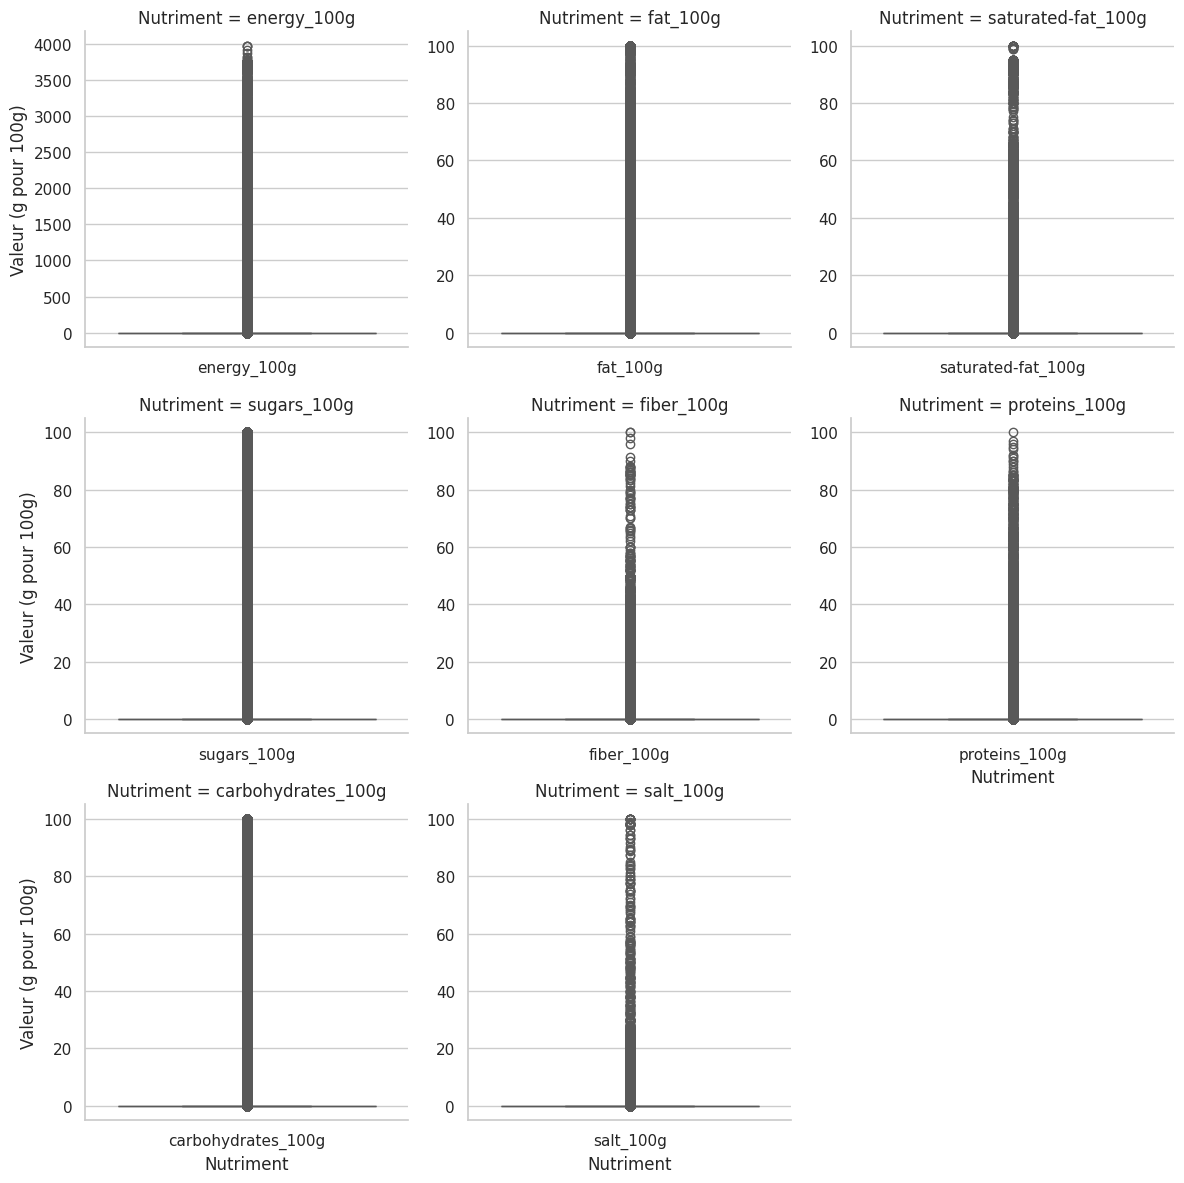

In [18]:
# 3. On crée la visualisation (facettes par nutriment)
sns.set_theme(style="whitegrid")
g = sns.FacetGrid(df_melted, col="Nutriment", col_wrap=3, sharex=False, sharey=False, height=4)
g.map(sns.boxplot, "Nutriment", "Valeur (g pour 100g)", order=None, palette="Set2")

<Axes: xlabel='nutriscore_grade', ylabel='sugars_100g'>

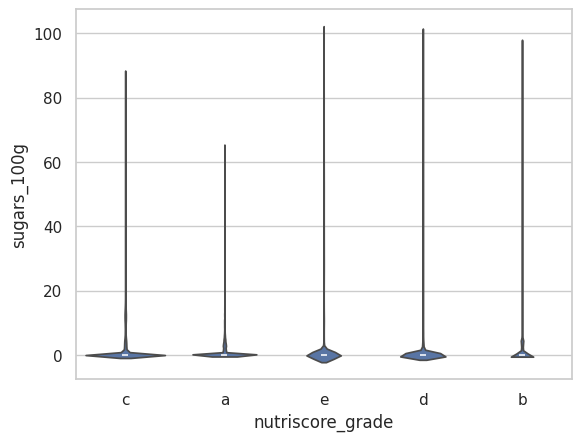

In [14]:
sns.violinplot(x=df['nutriscore_grade'], y=df['sugars_100g'], data=df)

In [4]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 206 columns):
 #    Column                                                 Dtype  
---   ------                                                 -----  
 0    code                                                   int64  
 1    url                                                    object 
 2    creator                                                object 
 3    created_t                                              int64  
 4    created_datetime                                       object 
 5    last_modified_t                                        int64  
 6    last_modified_datetime                                 object 
 7    last_modified_by                                       object 
 8    last_updated_t                                         int64  
 9    last_updated_datetime                                  object 
 10   product_name                                           object

### A partir du format parquet 

parquet est un format optimisé pour la maniupulation de gros data set

on peut charger le data set sous ce format, à partir de [son emplacement sur HuggingFace](https://huggingface.co/datasets/openfoodfacts/product-database) (attention il faudra installer les librairies suivantes pour cela) 

Si ca n'est pas déja fait, télécharger les librairies nécessaires : 
```
pip install huggingface-hub
pip fastparquet

```

In [ ]:
# Login using e.g. `huggingface-cli login` to access this dataset
splits = {'food': 'food.parquet', 'beauty': 'beauty.parquet'}
df = pd.read_parquet("hf://datasets/openfoodfacts/product-database/" + splits["food"])

### Autres méthodes

Pour des détails complets sur les différentes options pour charger les données, consultez la [page dédiée du projet](https://world.openfoodfacts.org/data)